In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

# Deep Neural Networks 
## Template 02
- multi-class - Fashion MNIST dataset (all 60000 images)

<img src='../../prasami_images/prasami_color_tutorials_small.png' width='400' alt="By Pramod Sharma : pramod.sharma@prasami.com"/>

In [2]:
###-----------------
### Import Libraries
###-----------------

###-----------------
### Import libraries
###-----------------
from pathlib import Path  # Import Path for file system path operations and management
import numpy as np  # Import NumPy for numerical computations and array operations
import pandas as pd  # Import Pandas for data manipulation and analysis with DataFrames
import matplotlib.pyplot as plt  # Import Matplotlib for creating static, interactive visualizations
import seaborn as sns  # Import Seaborn for statistical data visualization built on Matplotlib
import tensorflow as tf
from sklearn.model_selection import train_test_split  # Import function to split dataset into training and testing subsets
from sklearn.metrics import accuracy_score, classification_report , confusion_matrix,ConfusionMatrixDisplay,f1_score
                                                            # Import function to calculate various metric

# from utils.helper import fn_plot_confusion_matrix

In [3]:

###----------------------
### Plot confusion matrix
###----------------------
def fn_plot_confusion_matrix(y_true, y_pred, labels):
    '''
    Args:
        y_true: Ground Truth 
        y_pred : Predictions
        labels : labels in a dictonary 
                  {0: 'Goal Keeper', 
                  1: 'Defender', 
                  2: 'Mid-Fielder', 
                  3: 'Forward'}
    
    '''

    cm  = confusion_matrix(y_true, y_pred)
    
    if isinstance(labels, dict):
        display_labels = labels.values()
    else:
        display_labels = labels

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=display_labels)
    
    fig, ax = plt.subplots(figsize = (5,5))
    
    disp.plot(ax = ax, cmap = 'Blues', xticks_rotation = 'vertical', colorbar=False)
    
    # Disable the grid
    ax.grid(False)
    
    title_str = f'F1 Score : {f1_score(y_true, y_pred, average='weighted'):0.5f}'
    ax.set_title(title_str)

    plt.show()


In [4]:
# Some basic parameters
#inpDir = '../../input' 
# inpDir = Path('..') / '..' / 'input'
# # outDir = '../output'
# outDir = Path('..') / 'output'
# subDir = 'fashion_MNIST' # location of the images
# modelDir = Path('..') / 'models'
# altName = '?????'

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
rng = np.random.default_rng(seed = RANDOM_STATE) # Set Random Seed for reproducible  results
np.random.seed(RANDOM_STATE)

EPOCHS = 100 # number of cycles to run
ALPHA = 0.001 # learning rate
BATCH_SIZE=32
TEST_SIZE=0.2
# Set parameters for decoration of plots
params = {'legend.fontsize' : 'large',
          'figure.figsize'  : (9,9),
          'axes.labelsize'  : 'x-large',
          'axes.titlesize'  :'x-large',
          'xtick.labelsize' :'large',
          'ytick.labelsize' :'large',
         }

plt.rcParams.update(params) # update rcParams
CMAP = plt.cm.coolwarm
plt.style.use('seaborn-v0_8-darkgrid') # plt.style.use('ggplot')

In [5]:
#check if any GPU is available
physical_devices=tf.config.list_physical_devices('GPU')


#if there are, set memory growth to True
if len(physical_devices)>0:
    tf.config.experimental.set_memory_growth(physical_devices[0],True)

## Load Fashion MNIST dataset

This guide uses the [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist) dataset which contains 70,000 grayscale images in 10 categories. The images show individual articles of clothing at low resolution (28 by 28 pixels), as seen here:

<table>
  <tr><td>
    <img src="https://tensorflow.org/images/fashion-mnist-sprite.png"
         alt="Fashion MNIST sprite"  width="600">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1.</b> <a href="https://github.com/zalandoresearch/fashion-mnist">Fashion-MNIST samples</a> (by Zalando, MIT License).<br/>&nbsp;
  </td></tr>
</table>

Fashion MNIST is intended as a drop-in replacement for the classic [MNIST](http://yann.lecun.com/exdb/mnist/) dataset—often used as the "Hello, World" of machine learning programs for computer vision. The MNIST dataset contains images of handwritten digits (0, 1, 2, etc.) in a format identical to that of the articles of clothing you'll use here.

This guide uses Fashion MNIST for variety, and because it's a slightly more challenging problem than regular MNIST. Both datasets are relatively small and are used to verify that an algorithm works as expected. They're good starting points to test and debug code.

Here, 60,000 images are used to train the network and 10,000 images to evaluate how accurately the network learned to classify images. You can access the Fashion MNIST directly from TensorFlow. Import and [load the Fashion MNIST data](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/fashion_mnist/load_data) directly from TensorFlow:

In [6]:
train_filename ='./fashion-mnist_train.csv'
test_filename = './fashion-mnist_test.csv'

train_df = pd.read_csv(train_filename, header = 0)
test_df = pd.read_csv(test_filename, header = 0)

<table>
  <tr>
    <th>Label</th>
    <th>Class</th>
  </tr>
  <tr>
    <td>0</td>
    <td>T-shirt/top</td>
  </tr>
  <tr>
    <td>1</td>
    <td>Trouser</td>
  </tr>
    <tr>
    <td>2</td>
    <td>Pullover</td>
  </tr>
    <tr>
    <td>3</td>
    <td>Dress</td>
  </tr>
    <tr>
    <td>4</td>
    <td>Coat</td>
  </tr>
    <tr>
    <td>5</td>
    <td>Sandal</td>
  </tr>
    <tr>
    <td>6</td>
    <td>Shirt</td>
  </tr>
    <tr>
    <td>7</td>
    <td>Sneaker</td>
  </tr>
    <tr>
    <td>8</td>
    <td>Bag</td>
  </tr>
    <tr>
    <td>9</td>
    <td>Ankle boot</td>
  </tr>
</table>

Each image is mapped to a single label. Since the *class names* are not included with the dataset, store them here to use later when plotting the images:

In [7]:
#class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
#               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

class_names = {0: 'T-shirt/top',1:'Trouser',2:'Pullover',3:'Dress',4:'Coat',
               5:'Sandal', 6: 'Shirt',7: 'Sneaker', 8:'Bag', 9: 'Ankle boot'}

## Explore the data

Let's explore the format of the dataset before training the model. The following shows there are 60,000 images in the training set, with each image represented as 28 x 28 pixels:

In [8]:
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
train_df.columns

Index(['label', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6',
       'pixel7', 'pixel8', 'pixel9',
       ...
       'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779', 'pixel780',
       'pixel781', 'pixel782', 'pixel783', 'pixel784'],
      dtype='str', length=785)

In [10]:
train_df.shape, test_df.shape

((60000, 785), (10000, 785))

Each label is an integer between 0 and 9:

In [11]:
train_df['label'].unique()

array([2, 9, 6, 0, 3, 4, 5, 8, 7, 1])

## Whats in the data?

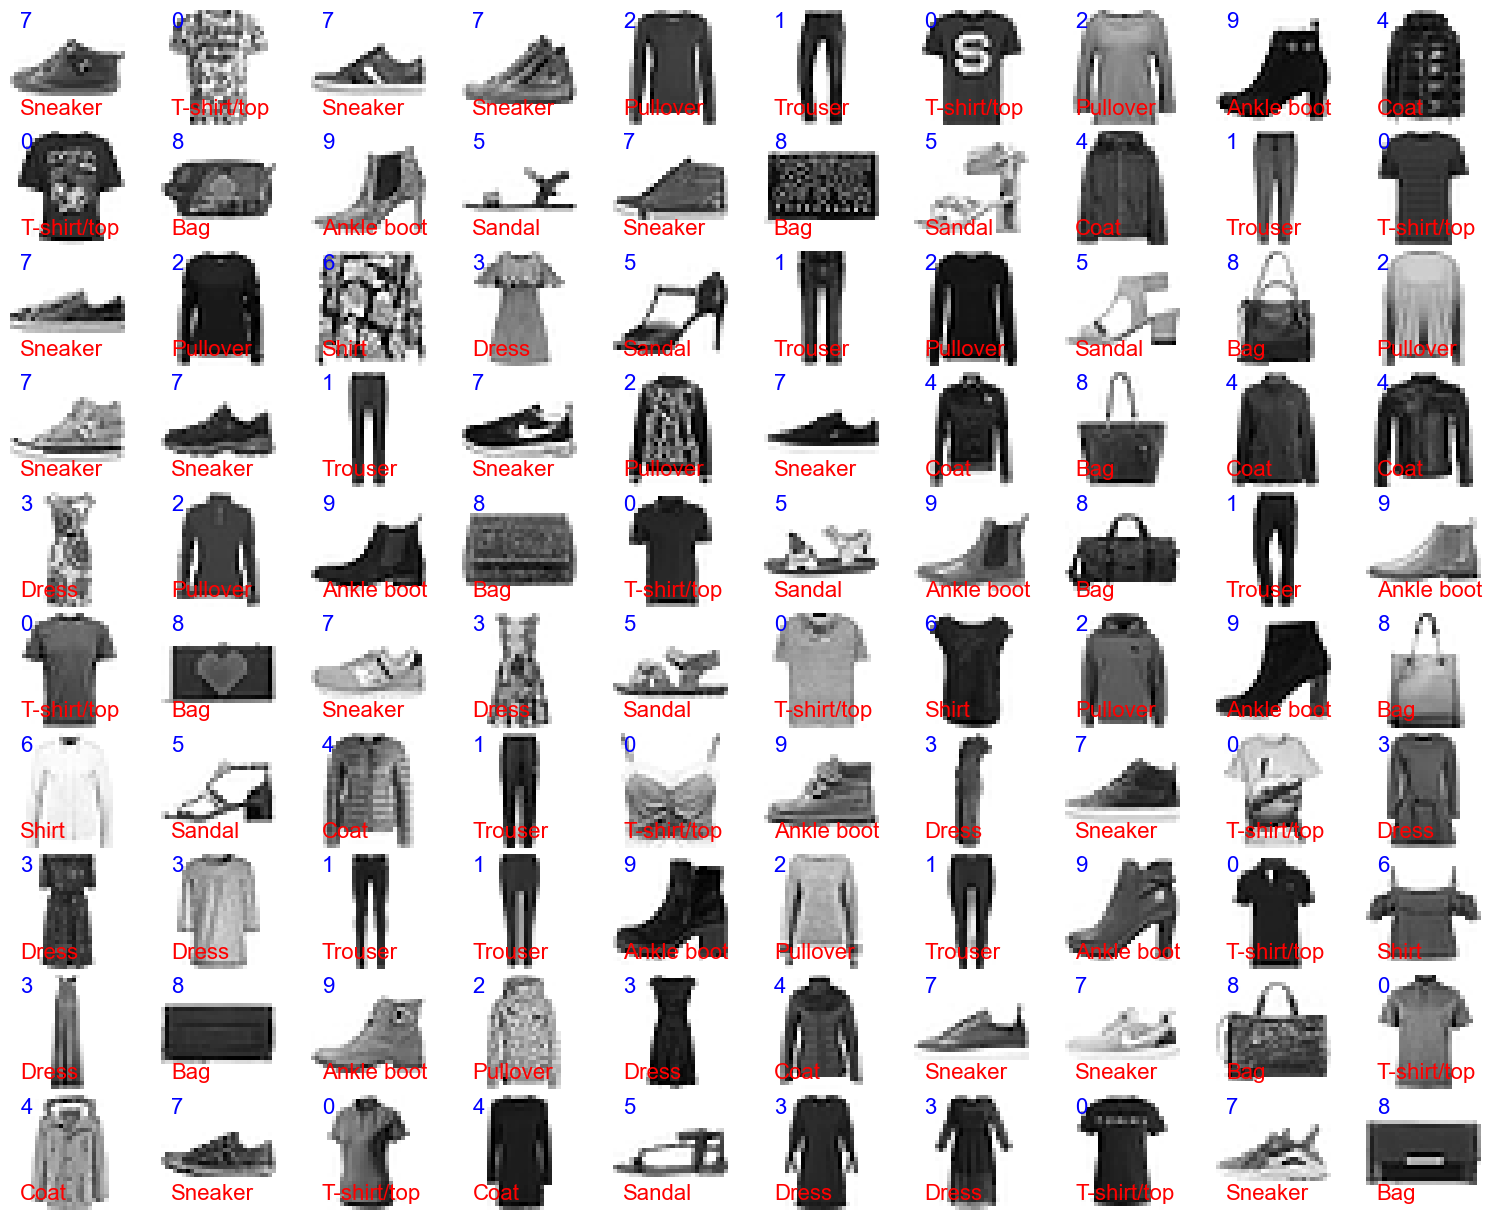

In [12]:
# Sample data plot

plot_df = train_df.sample(n = 100) # Take 100 sample from the training set

fig = plt.figure(figsize=(15, 12))  # figure size in inches

fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05) # adjust subplots

i = 0

for _ , row in plot_df.iterrows(): # iterate through all rows of the dataframe
    
    i = i + 1
    
    image = row.values[1:].reshape(28,28) # reshape row to a 28x28 matrix
    
    ax = fig.add_subplot(10, 10, (i), xticks=[], yticks=[]) # add a subplot to the figure
    
    ax.imshow(image, cmap=plt.cm.binary, interpolation='nearest') # show image on the axis
    
    ax.text(2, 4, str(row.iloc[0]), color='b', fontsize=16)   # add number (class) of the image
    
    ax.text(2, 25, class_names[row.iloc[0]], color='r', fontsize=16)   # add name of the image
    
plt.show()

## Preprocess the data

The data must be preprocessed before training the network. If you inspect the first image in the training set, you will see that the pixel values fall in the range of 0 to 255:

Scale these values to a range of 0 to 1 before feeding them to the neural network model. To do so, divide the values by 255. It's important that the *training set* and the *testing set* be preprocessed in the same way:

In [13]:
X_train = train_df.drop('label', axis = 1).to_numpy()
y_train = train_df['label'].to_numpy()

X_test = test_df.drop('label', axis = 1).to_numpy()
y_test = test_df['label'].to_numpy()

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((60000, 784), (10000, 784), (60000,), (10000,))

In [14]:
#normalising data
X_train = X_train / 255.0

X_test = X_test / 255.0

In [15]:
train_ds=tf.data.Dataset.from_tensor_slices((X_train,y_train))
test_ds=tf.data.Dataset.from_tensor_slices((X_test,y_test))

In [16]:
train_ds=train_ds.cache()
train_ds=train_ds.prefetch(tf.data.AUTOTUNE)

test_ds=test_ds.cache()
test_ds=test_ds.prefetch(tf.data.AUTOTUNE)

In [17]:
#SHUFFLE AND BTACHING
train_ds=train_ds.shuffle(buffer_size=X_train.shape[0]).batch(BATCH_SIZE)

test_ds=test_ds.shuffle(buffer_size=X_test.shape[0]).batch(BATCH_SIZE)

In [18]:
#always check data before proceeding
for features,labels in train_ds.take(1):
    print(features.shape,labels.shape)

(32, 784) (32,)


In [21]:
#define model
dor1=0.2
dor2=0.4
optimizer=tf.keras.optimizers.Adam(learning_rate=ALPHA)

regularizer= tf.keras.regularizers.L2(0.05
                                     )
loss_fn=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
# for one hidden layers- 784/8 - 98
# for 2 hidden layers-  782/4 - 196,   196/4=49
model=tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),
    
    tf.keras.layers.Dense(196),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(rate=dor1),
    tf.keras.layers.Activation(activation='relu'),
    
    tf.keras.layers.Dense(49),
    tf.keras.layers.BatchNormalization(),
     tf.keras.layers.Dropout(rate=dor2),
    tf.keras.layers.Activation(activation='relu'),
    
    tf.keras.layers.Dense(10)
])



In [22]:
model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=['accuracy'])

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 196)            │       153,860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 196)            │           784 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 196)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 196)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 49)             │         9,653 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 49)             │           196 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 49)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 49)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,993 (644.50 KB)

 Trainable params: 164,503 (642.59 KB)

 Non-trainable params: 490 (1.91 KB)

In [24]:
hist=model.fit(train_ds,epochs=EPOCHS,batch_size=BATCH_SIZE,validation_data=test_ds)

Epoch 1/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.7846 - loss: 0.6392 - val_accuracy: 0.8526 - val_loss: 0.4107
Epoch 2/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8316 - loss: 0.4827 - val_accuracy: 0.8449 - val_loss: 0.4077
Epoch 3/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8463 - loss: 0.4398 - val_accuracy: 0.8569 - val_loss: 0.3898
Epoch 4/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8525 - loss: 0.4163 - val_accuracy: 0.8673 - val_loss: 0.3579
Epoch 5/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8602 - loss: 0.3935 - val_accuracy: 0.8803 - val_loss: 0.3278
Epoch 6/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8651 - loss: 0.3821 - val_accuracy: 0.8770 - val_loss: 0.3257
Epoch 7/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8684 - loss: 0.3680 - val_accuracy: 0.8869 - val_loss: 0.3135
Epoch 8/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8726 -

In [25]:
loss_df=pd.DataFrame(hist.history)
loss_df.head()

,accuracy,loss,val_accuracy,val_loss
0,0.784583,0.639195,0.8526,0.410676
1,0.831617,0.482735,0.8449,0.407669
2,0.846317,0.439757,0.8569,0.389778
3,0.852500,0.416324,0.8673,0.357934
4,0.860200,0.393501,0.8803,0.327782


In [26]:
###-----------------------------------------------------------
### Function to plot Loss Curve using Tensorflow history object
###------------------------------------------------------------

def fn_plot_tf_hist(hist_df):
    
    '''
    Args:
        hist_df: a DataFrame with column names accuracy,loss	val_accuracy	val_loss
    '''
        
    fig, axes = plt.subplots(1,2 , figsize = (15,6))

    # properties  matplotlib.patch.Patch 
    props = dict(boxstyle='round', facecolor='aqua', alpha=0.4)
    facecolor = 'cyan'
    fontsize=12
    CMAP = plt.cm.coolwarm
    
    # Get columns by index to eliminate any column naming error
    y1 = hist_df.columns[0]
    y2 = hist_df.columns[1]
    y3 = hist_df.columns[2]
    y4 = hist_df.columns[3]

    # Where was min loss
    best = hist_df[hist_df[y4] == hist_df[y4].min()]
    
    ax = axes[0]

    hist_df.plot(y = [y2,y4], ax = ax, colormap=CMAP)


    # little beautification
    txtFmt = "Loss: \n  train: {:6.4f}\n   test: {:6.4f}"
    txtstr = txtFmt.format(hist_df.iloc[-1][y2],
                           hist_df.iloc[-1][y4]) #text to plot
    
    # place a text box in upper middle in axes coords
    ax.text(0.3, 0.95, txtstr, transform=ax.transAxes, fontsize=fontsize,
            verticalalignment='top', bbox=props)
    
    # calculate offset for arrow
    y_min = min(hist_df[y2].min(), hist_df[y4].min())
    y_max = max(hist_df[y2].max(), hist_df[y4].max())
    offset = (y_max-y_min)/10.0
    
    best_idx = best.index.to_numpy()[0]  # Extract first (and only) element as scalar
    best_value = best[y4].to_numpy()[0]   # Extract scalar value
    
    # Mark arrow at lowest
    ax.annotate(f'Min: {best_value:6.4f}', # text to print
                xy=(best_idx, best_value), # Arrow start
                xytext=(best_idx, best_value + offset), # location of text 
                fontsize=fontsize, va='bottom', ha='right',bbox=props, # beautification of text
                arrowprops=dict(facecolor=facecolor, shrink=0.05)) # arrow
    
    # Draw vertical line at best value
    ax.axvline(x = best_idx, color = 'green', linestyle='-.', lw = 3)

    ax.set_xlabel("Epochs")
    ax.set_ylabel(y2.capitalize())
    ax.set_title('Loss Curve')
    ax.grid(True)
    ax.legend(loc = 'upper left') # model legend to upper left
    
    ax = axes[1]

    hist_df.plot( y = [y1, y3], ax = ax, colormap=CMAP)
    
    # little beautification
    txtFmt = "Accuracy: \n  train: {:6.4f}\n  test:  {:6.4f}"
    txtstr = txtFmt.format(hist_df.iloc[-1][y1],
                           hist_df.iloc[-1][y3]) #text to plot

    # place a text box in upper middle in axes coords
    ax.text(0.3, 0.2, txtstr, transform=ax.transAxes, fontsize=fontsize,
            verticalalignment='top', bbox=props)

    # calculate offset for arroe
    y_min = min(hist_df[y1].min(), hist_df[y3].min())
    y_max = max(hist_df[y1].max(), hist_df[y3].max())
    offset = (y_max-y_min)/10.0

    best_value = best[y3].to_numpy()[0]   # Extract scalar value
    # Mark arrow at lowest
    ax.annotate(f'Best: {best_value:6.4f}', # text to print
                xy=(best_idx, best_value), # Arrow start
                xytext=(best_idx, best_value-offset), # location of text 
                fontsize=fontsize, va='bottom', ha='right',bbox=props, # beautification of text
                arrowprops=dict(facecolor=facecolor, shrink=0.05)) # arrow
    
    
    # Draw vertical line at best value
    ax.axvline(x = best_idx, color = 'green', linestyle='-.', lw = 3)

    ax.set_xlabel("Epochs")
    ax.set_ylabel(y1.capitalize())
    ax.set_title('Accuracy Curve')
    ax.grid(True)
    ax.legend(loc = 'lower left')
    
    plt.tight_layout()
    

In [27]:
def fn_plot_confusion_matrix(y_true, y_pred, labels):
    '''
    Args:
        y_true: Ground Truth 
        y_pred : Predictions
        labels : dictonary
    
    '''
    
    cm  = confusion_matrix(y_true, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels.values())
    
    fig, ax = plt.subplots(figsize = (4,4))
    
    disp.plot(ax = ax, cmap = 'Blues', xticks_rotation = 'vertical', colorbar=False)
    # Disable the grid
    ax.grid(False)
    ax.set_title(f"F1_Score: {f1_score(y_test,y_pred, average='weighted'):0.4f}")
    plt.show()

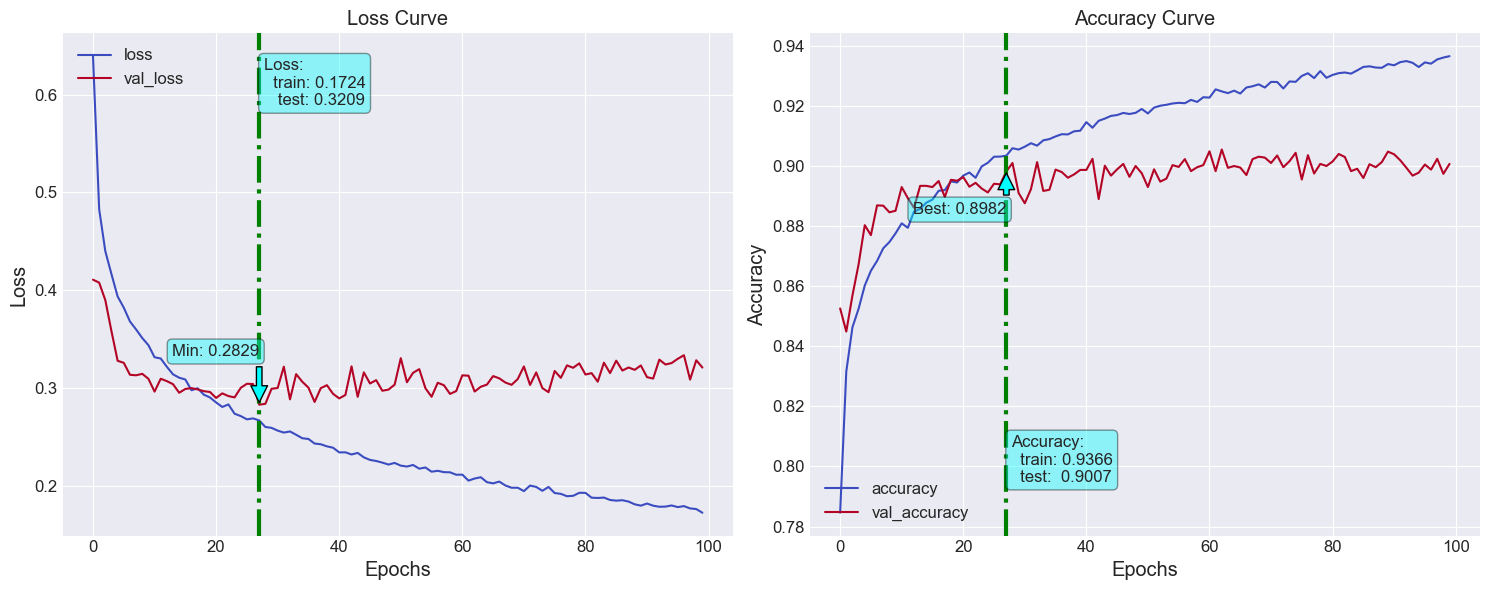

In [28]:
fn_plot_tf_hist(loss_df)

In [29]:
loss_df[loss_df['val_loss'] == loss_df['val_loss'].min()]

,accuracy,loss,val_accuracy,val_loss
27,0.90345,0.26681,0.8982,0.28291


In [30]:
probability_model = tf.keras.Sequential([
  model,
  tf.keras.layers.Softmax()
])

In [31]:
y_pred = probability_model(X_train).numpy()
y_pred.shape

(60000, 10)

In [32]:
accuracy_score(y_train, y_pred.argmax(axis=1))

0.9685333333333334

In [33]:
print(classification_report( y_train, y_pred.argmax( axis = 1)))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94      6000
           1       1.00      1.00      1.00      6000
           2       0.91      0.97      0.94      6000
           3       0.96      0.99      0.98      6000
           4       0.95      0.93      0.94      6000
           5       1.00      1.00      1.00      6000
           6       0.97      0.83      0.90      6000
           7       0.99      1.00      0.99      6000
           8       1.00      1.00      1.00      6000
           9       1.00      0.99      0.99      6000

    accuracy                           0.97     60000
   macro avg       0.97      0.97      0.97     60000
weighted avg       0.97      0.97      0.97     60000



In [34]:
y_pred = probability_model(X_test).numpy()

print('Accuracy score on Test Data :{:.5f}'.format(accuracy_score(y_test, 
                                                                  np.argmax(y_pred, axis = 1))))

Accuracy score on Test Data :0.90070


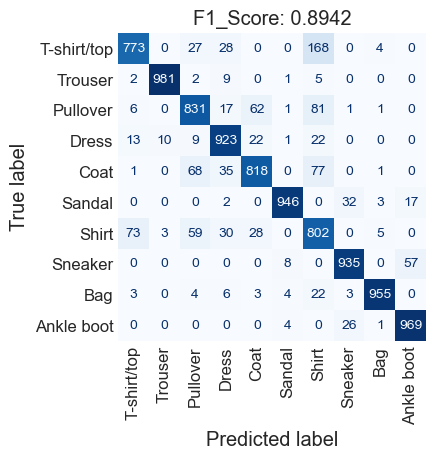

In [34]:

fn_plot_confusion_matrix(y_test,y_pred.argmax(axis=1),labels=class_names)